# Data Description

In [62]:
# libraries
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib import pyplot as plt
import warnings

warnings.filterwarnings(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [63]:
# import data
df = pd.read_csv('datasets/datasets/aerofit_treadmill_data.csv')

## Data Types

In [64]:
# Data Types of Columns
def df_datatypes(df):
    df_desc = pd.DataFrame(df.dtypes.value_counts().reset_index())
    df_desc.columns = ['Data Type', 'Count']
    return df_desc.sort_values('Count', ascending=False)

df_datatypes(df)

,Data Type,Count
0,int64,6
1,str,3


## Missing Info

In [87]:
# DataFrame info
import pandas as pd
import numpy as np

def get_df_info(df: pd.DataFrame) -> pd.DataFrame:
    df_info = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes,
        'Non-Null Count': df.notnull().sum(),
        '# Null': df.isna().sum()
    }).reset_index(drop=True)
    
    total_rows = len(df)
    df_info['Total Count'] = total_rows
    
    if total_rows > 0:
        null_pct = (df_info['# Null'] / total_rows * 100).round(2)
        df_info['% Null'] = null_pct.astype(str) + '%'
    else:
        df_info['% Null'] = '0.0%'
        
    return df_info

get_df_info(df)

,Column,Data Type,Non-Null Count,# Null,Total Count,% Null
0,Product,str,180,0,180,0.0%
1,Age,int64,180,0,180,0.0%
2,Gender,str,180,0,180,0.0%
3,Education,int64,180,0,180,0.0%
4,MaritalStatus,str,180,0,180,0.0%
5,Usage,int64,180,0,180,0.0%
6,Fitness,int64,180,0,180,0.0%
7,Income,int64,180,0,180,0.0%
8,Miles,int64,180,0,180,0.0%


In [66]:
# Numerical Info
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
get_df_info(df[numeric_columns])

,Column,Data Type,Non-Null Count,# Null,Total Count,% Null
0,Age,int64,180,0,180,0.0%
1,Education,int64,180,0,180,0.0%
2,Usage,int64,180,0,180,0.0%
3,Fitness,int64,180,0,180,0.0%
4,Income,int64,180,0,180,0.0%
5,Miles,int64,180,0,180,0.0%


In [67]:
# Categorical Info
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
get_df_info(df[categorical_columns])

,Column,Data Type,Non-Null Count,# Null,Total Count,% Null
0,Product,str,180,0,180,0.0%
1,Gender,str,180,0,180,0.0%
2,MaritalStatus,str,180,0,180,0.0%


## Categorical

In [68]:
def df_describe_categorical(df: pd.DataFrame) -> pd.DataFrame:
    # get categorical columns
    cat_df = df.select_dtypes(exclude=np.number)

    # return empty dataframe if empty
    if cat_df.empty:
        return pd.DataFrame()

    # get number of observations
    counts = cat_df.count()

    # get missing
    n_missing = cat_df.isna().sum()

    # get number of unique values
    uniques = cat_df.nunique()

    # get mode
    modes_df = cat_df.mode().iloc[0]

    # get top categories
    top_categories = modes_df.astype(str)

    # get top category frequency
    top_freqs = (cat_df == modes_df).sum()

    # get percentage of top category
    top_pcts = ((top_freqs / counts).round(2) * 100).astype(int).astype(str) + "%"

    # build dataframe
    summary_df = pd.DataFrame(
        {
            "Column": cat_df.columns,
            "Data Type": cat_df.dtypes,
            "Count": counts,
            "Missing Values": n_missing,
            "Unique Values": uniques,
            "Top Category": top_categories,
            "Top Category Frequency": top_freqs,
            "% Top Category": top_pcts,
        }
    ).reset_index(drop=True)

    return summary_df

df_describe_categorical(df)

,Column,Data Type,Count,Missing Values,Unique Values,Top Category,Top Category Frequency,% Top Category
0,Product,str,180,0,3,KP281,80,44%
1,Gender,str,180,0,2,Male,104,57%
2,MaritalStatus,str,180,0,2,Partnered,107,59%


## Numerical

In [69]:
# Numeric Description
def get_describe_numeric(df: pd.DataFrame, precision: int = 4) -> pd.DataFrame:
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.empty:
        return pd.DataFrame()

    desc = numeric_df.describe(percentiles=[0.25, 0.50, 0.75]).T.reset_index()
    desc = desc.rename(columns={
        'index': 'Column', 
        'count': 'Count', 
        'mean': 'Mean', 
        'std': 'Std Dev', 
        'min': 'Min',
        'max': 'Max'
    })

    desc['Data Type'] = numeric_df.dtypes.values
    desc['Missing'] = numeric_df.isna().sum().values

    normality = pg.normality(numeric_df, method='jarque_bera').reset_index()
    normality = normality.rename(columns={'index': 'Column'})

    final_cols = [
        'Column', 'Data Type', 'Count', 'Missing', 'Mean', 
        'Std Dev', 'Min', '25%', '50%', '75%', 'Max', 'normal', 'pval'
    ]

    summary_df = pd.merge(desc, normality[['Column', 'normal', 'pval']], on='Column')
    
    return summary_df[final_cols].round(precision)

get_describe_numeric(df)

,Column,Data Type,Count,Missing,Mean,Std Dev,Min,25%,50%,75%,Max,normal,pval
0,Age,int64,180.0,0,28.7889,6.9435,18.0,24.00,26.0,33.00,50.0,False,0.0000
1,Education,int64,180.0,0,15.5722,1.6171,12.0,14.00,16.0,16.00,21.0,False,0.0001
2,Usage,int64,180.0,0,3.4556,1.0848,2.0,3.00,3.0,4.00,7.0,False,0.0001
3,Fitness,int64,180.0,0,3.3111,0.9589,1.0,3.00,3.0,4.00,5.0,False,0.0266
4,Income,int64,180.0,0,53719.5778,16506.6842,29562.0,44058.75,50596.5,58668.00,104581.0,False,0.0000
5,Miles,int64,180.0,0,103.1944,51.8636,21.0,66.00,94.0,114.75,360.0,False,0.0000


### Correlogram

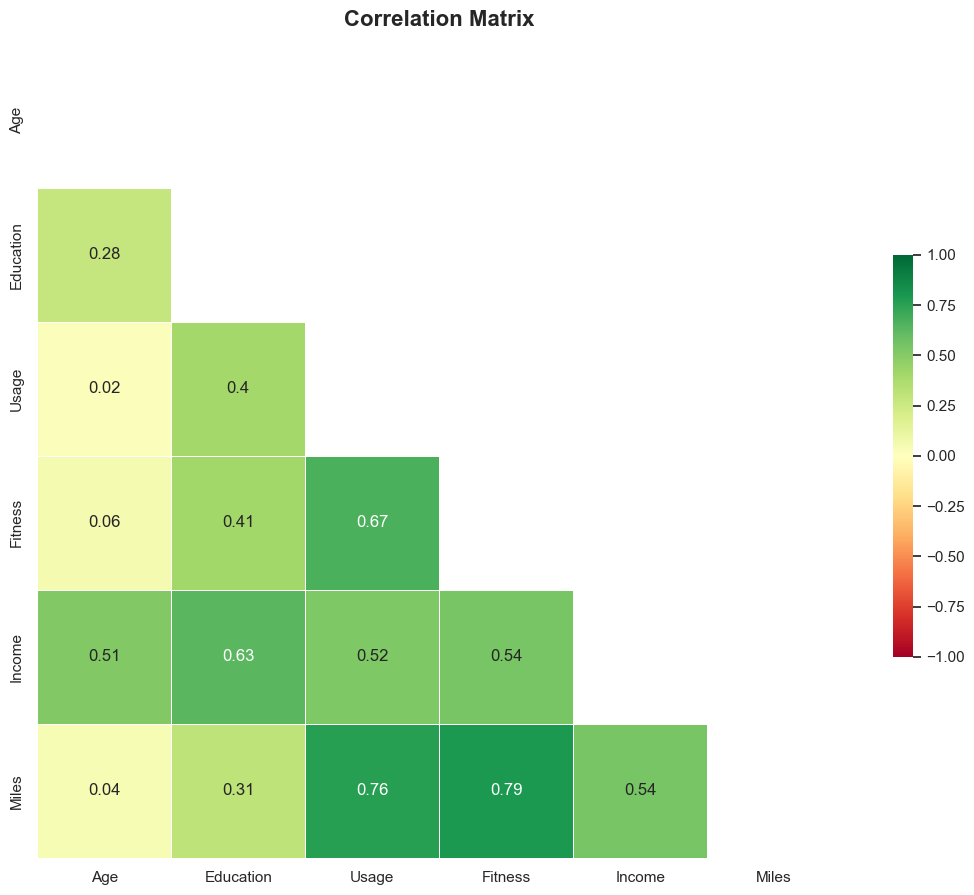

In [89]:
# numerical - correlogram
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def graph_correlogram(df: pd.DataFrame, precision: int = 2) -> plt.Axes:
    corr = df.corr(numeric_only=True).round(precision)
    
    if corr.empty:
        print("Warning: No numeric columns available to correlate.")
        return None

    mask = np.triu(np.ones_like(corr, dtype=bool))

    with sns.axes_style("white"):
        fig, ax = plt.subplots(figsize=(11, 9))
        
        sns.heatmap(
            corr, 
            mask=mask, 
            cmap='RdYlGn', 
            vmin=-1, 
            vmax=1, 
            center=0, 
            square=True,
            annot=True, 
            linewidths=.5,
            cbar_kws={"shrink": .5}, 
            annot_kws={"fontsize": 12}, 
            ax=ax
        )
        
        plt.title("Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        
    return ax

graph_correlogram(df)
plt.show()

### Correlation Matrix

In [71]:
# correlation matrix with p-values
def df_correlation_matrix(df):
    numerical = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f'Pearson Correlation Matrix with P-Values')
    print(f'[Coef in Btm Tri / p-Values in Up Tri]')
    print(f'*** for <0.001, ** for <0.01, * for <0.05')
    print(f'-----------------------------------------')
    return df[numerical].rcorr(method='pearson').round(3)

df_correlation_matrix(df)

Pearson Correlation Matrix with P-Values
[Coef in Btm Tri / p-Values in Up Tri]
*** for <0.001, ** for <0.01, * for <0.05
-----------------------------------------


,Age,Education,Usage,Fitness,Income,Miles
Age,-,***,,,***,
Education,0.28,-,***,***,***,***
Usage,0.015,0.395,-,***,***,***
Fitness,0.061,0.411,0.669,-,***,***
Income,0.513,0.626,0.52,0.535,-,***
Miles,0.037,0.307,0.759,0.786,0.543,-


# Histograms of Numerical

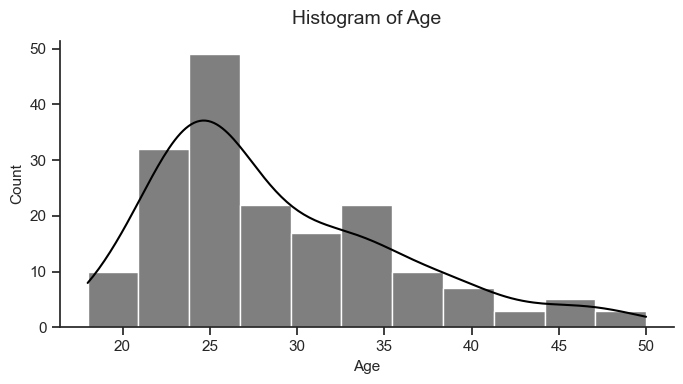

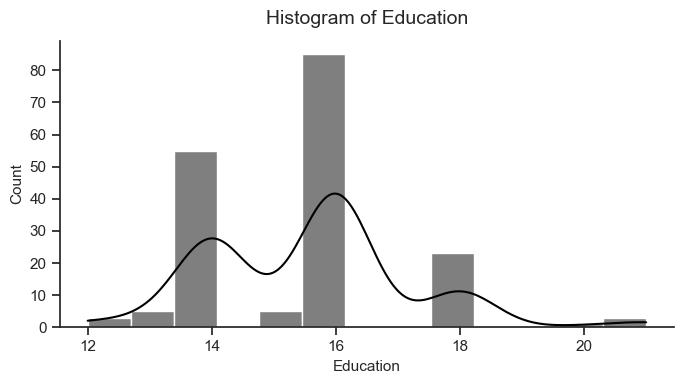

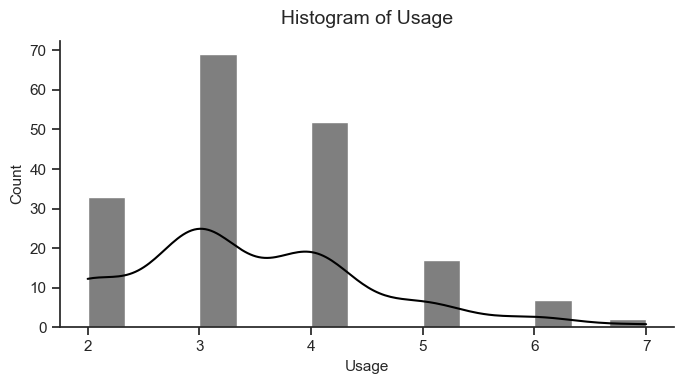

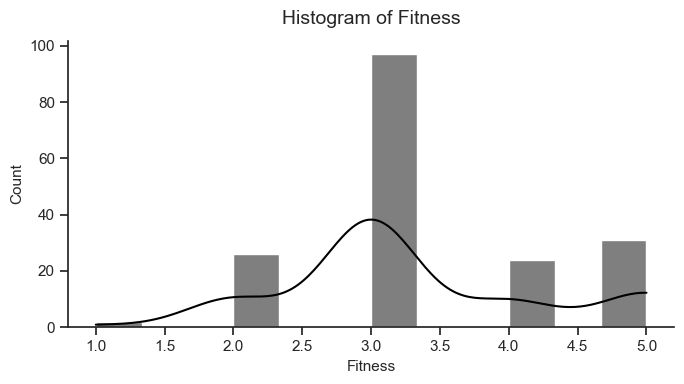

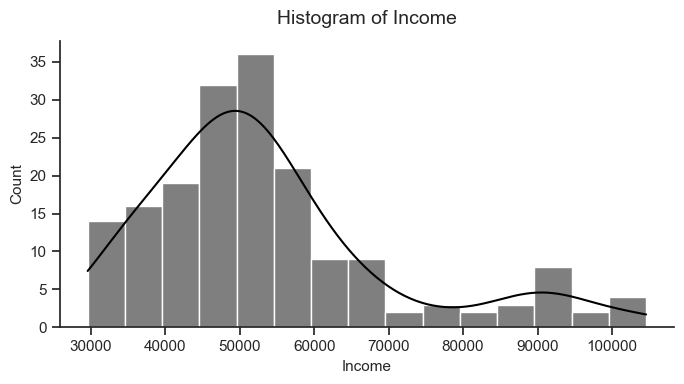

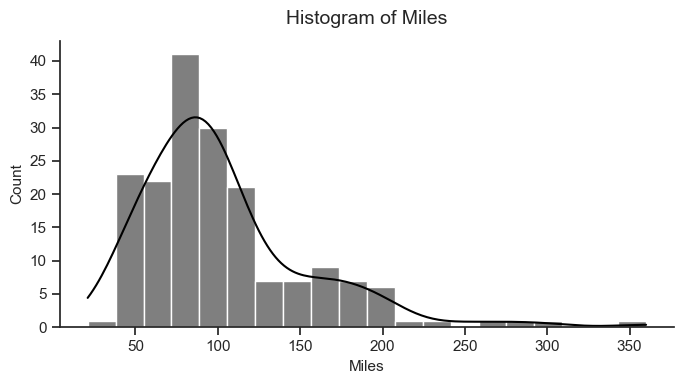

In [90]:
# graph of all numeric data types
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def graph_numeric_histograms(df: pd.DataFrame) -> None:
    
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_columns) == 0:
        print("Warning: No numeric columns found to plot.")
        return

    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    
    with sns.axes_style("ticks", rc=custom_params):
        for col in numeric_columns:
            fig, ax = plt.subplots(figsize=(7, 4))
            
            sns.histplot(data=df, x=col, kde=True, color='black', ax=ax)
            
            ax.set_title(f'Histogram of {col.title()}', fontsize=14, pad=12)
            ax.set_xlabel(col.title(), fontsize=11)
            ax.set_ylabel('Count', fontsize=11)
            
            plt.tight_layout()
            plt.show()
    
graph_numeric_histograms(df)

# Analysis of Variation

## All vs Product

In [73]:
import warnings
import pandas as pd
import numpy as np
import pingouin as pg

def get_anova_df(target: str, df: pd.DataFrame, is_target_cat: bool = True, precision: int = 4) -> pd.DataFrame:
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    if is_target_cat:
        features = df.select_dtypes(include=np.number).columns
    else:
        features = df.select_dtypes(exclude=np.number).columns

    if len(features) == 0:
        return pd.DataFrame()

    results = []
    for feat in features:
        dv_var = feat if is_target_cat else target
        between_var = target if is_target_cat else feat
        
        try:
            res = df.anova(dv=dv_var, between=between_var, detailed=False)
            
            res['Target'] = dv_var
            res['Source'] = between_var
            
            results.append(res)
        except Exception:
            continue

    if not results:
        return pd.DataFrame()

    anova_df = pd.concat(results, axis='rows', ignore_index=True)
    
    anova_df['S.S. Diff'] = np.where(anova_df['p_unc'] <= 0.05, 'Yes', 'No')
    
    final_cols = ['Target', 'Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2', 'S.S. Diff']
    return anova_df[final_cols].round(precision)

In [74]:
get_anova_df('Product', df, True)

,Target,Source,ddof1,ddof2,F,p_unc,np2,S.S. Diff
0,Age,Product,2,177,0.0942,0.9101,0.0011,No
1,Education,Product,2,177,45.1904,0.0000,0.3380,Yes
2,Usage,Product,2,177,65.4445,0.0000,0.4251,Yes
3,Fitness,Product,2,177,104.0013,0.0000,0.5403,Yes
4,Income,Product,2,177,89.2590,0.0000,0.5021,Yes
5,Miles,Product,2,177,68.2418,0.0000,0.4354,Yes


## Pairwise Test

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from IPython.display import display

def pw_comp(cat: str, num: str, data: pd.DataFrame) -> None:
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=cat, x=num, data=data)
    plt.suptitle(f'Boxplot of {cat.title()} vs {num.title()}')
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- Means by {cat.title()} ---")
    means_df = data.groupby(cat)[num].mean().to_frame()
    display(means_df)
    
    print(f"\n--- Pairwise Tukey Test ---")
    aov_df = pg.pairwise_tukey(dv=num, between=cat, data=data).round(4)
    
    if aov_df.empty:
        print("No pairs to compare or test failed.")
        return

    aov_df['S.S. Diff'] = np.where(aov_df['p_tukey'] <= 0.05, 'Yes', 'No')
    
    abs_hedges = aov_df['hedges'].abs()
    aov_df['Eff Size'] = pd.cut(
        abs_hedges, 
        bins=[-np.inf, 0.2, 0.5, np.inf], 
        labels=['Small', 'Medium', 'Large']
    )
    
    display(aov_df)

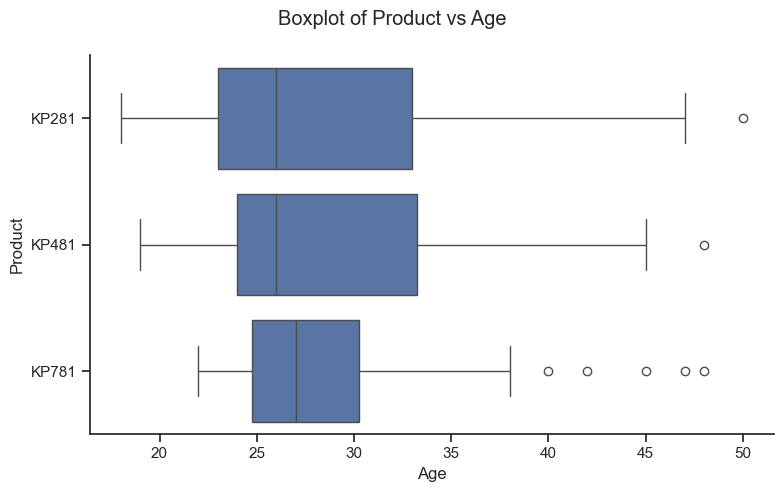


--- Means by Product ---


,Age
Product,
KP281,28.55
KP481,28.90
KP781,29.10



--- Pairwise Tukey Test ---


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,28.55,28.9,-0.35,1.1919,-0.2937,0.9536,-0.0499,No,Small
1,KP281,KP781,28.55,29.1,-0.55,1.3515,-0.4070,0.9128,-0.0765,No,Small
2,KP481,KP781,28.90,29.1,-0.20,1.4246,-0.1404,0.9892,-0.0293,No,Small


In [76]:
pw_comp('Product', 'Age', df)

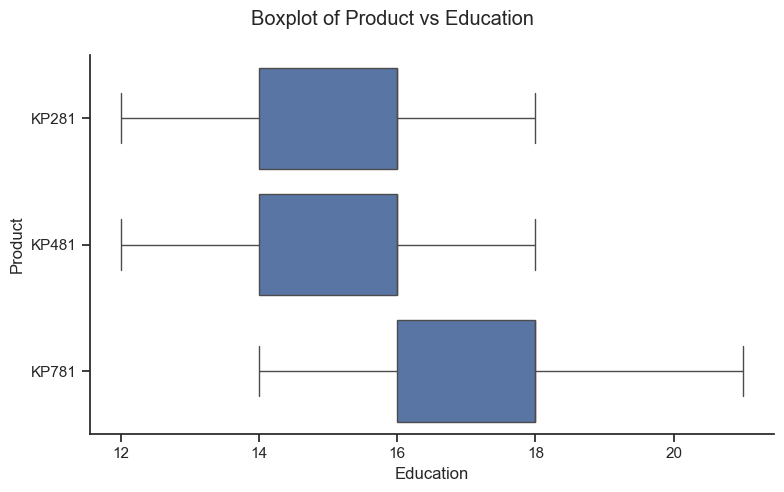


--- Means by Product ---


,Education
Product,
KP281,15.037500
KP481,15.116667
KP781,17.325000



--- Pairwise Tukey Test ---


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,15.0375,15.1167,-0.0792,0.2260,-0.3504,0.9346,-0.0646,No,Small
1,KP281,KP781,15.0375,17.3250,-2.2875,0.2562,-8.9281,0.0000,-1.6584,Yes,Large
2,KP481,KP781,15.1167,17.3250,-2.2083,0.2701,-8.1768,0.0000,-1.5617,Yes,Large


In [77]:
pw_comp('Product', 'Education', df)

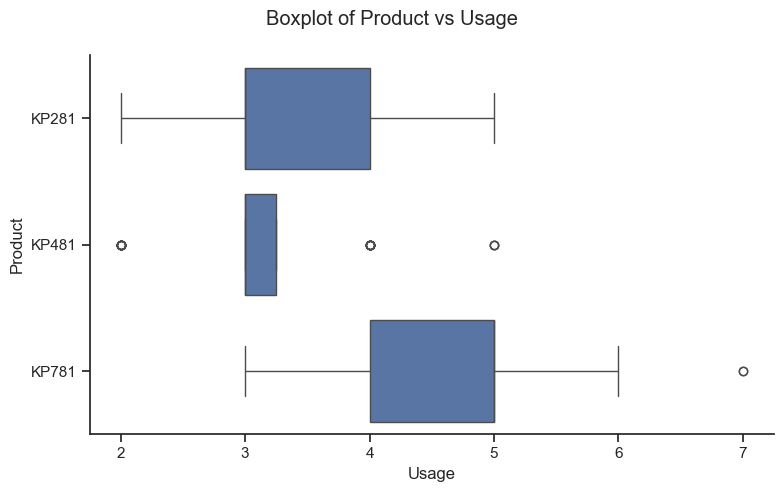


--- Means by Product ---


,Usage
Product,
KP281,3.087500
KP481,3.066667
KP781,4.775000



--- Pairwise Tukey Test ---


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,3.0875,3.0667,0.0208,0.1413,0.1475,0.9881,0.0262,No,Small
1,KP281,KP781,3.0875,4.7750,-1.6875,0.1602,-10.5354,0.0000,-1.9949,Yes,Large
2,KP481,KP781,3.0667,4.7750,-1.7083,0.1688,-10.1181,0.0000,-1.9681,Yes,Large


In [78]:
pw_comp('Product', 'Usage', df)

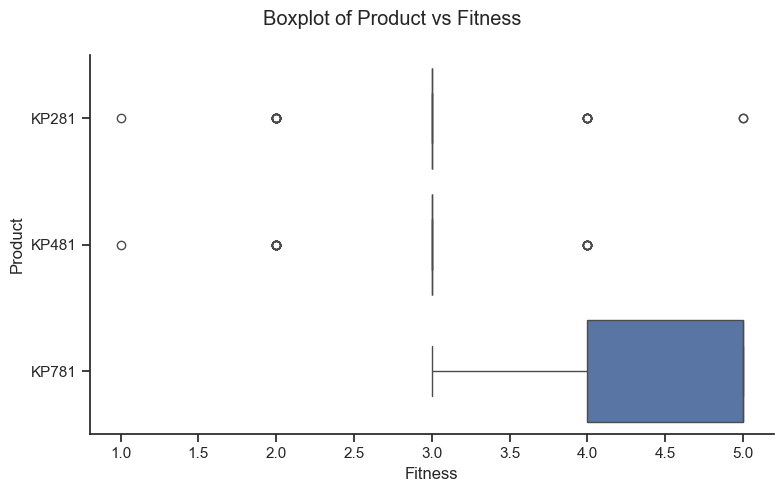


--- Means by Product ---


,Fitness
Product,
KP281,2.9625
KP481,2.9000
KP781,4.6250



--- Pairwise Tukey Test ---


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,2.9625,2.900,0.0625,0.1117,0.5597,0.8416,0.0956,No,Small
1,KP281,KP781,2.9625,4.625,-1.6625,0.1266,-13.1308,0.0000,-2.4822,Yes,Large
2,KP481,KP781,2.9000,4.625,-1.7250,0.1335,-12.9253,0.0000,-2.6538,Yes,Large


In [79]:
pw_comp('Product', 'Fitness', df)

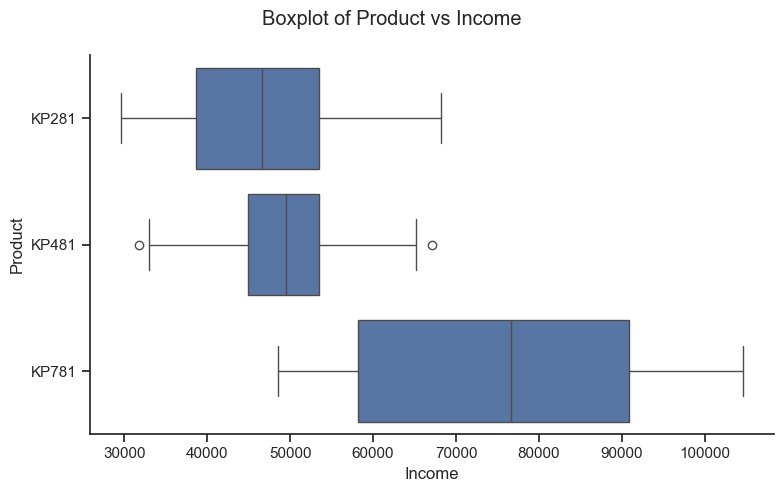


--- Means by Product ---


,Income
Product,
KP281,46418.025
KP481,48973.650
KP781,75441.575



--- Pairwise Tukey Test ---


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,46418.025,48973.650,-2555.625,2000.3174,-1.2776,0.4097,-0.2857,No,Medium
1,KP281,KP781,46418.025,75441.575,-29023.550,2268.1468,-12.7962,0.0000,-2.2227,Yes,Large
2,KP481,KP781,48973.650,75441.575,-26467.925,2390.8366,-11.0706,0.0000,-1.9502,Yes,Large


In [80]:
pw_comp('Product', 'Income', df)

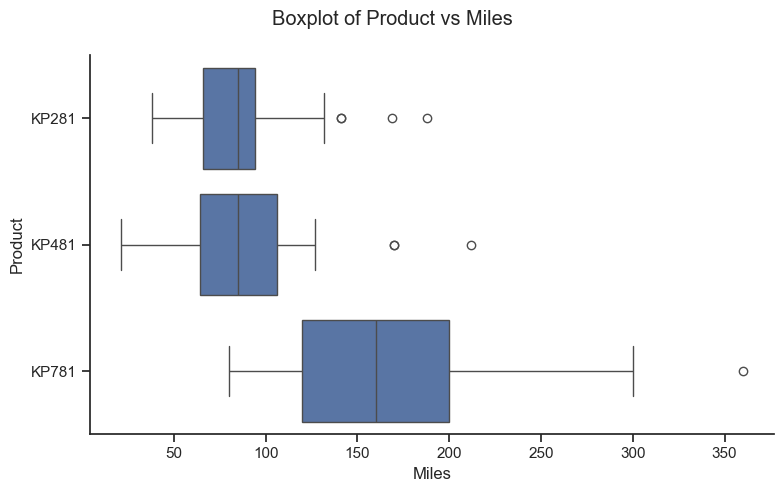


--- Means by Product ---


,Miles
Product,
KP281,82.787500
KP481,87.933333
KP781,166.900000



--- Pairwise Tukey Test ---


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,82.7875,87.9333,-5.1458,6.6931,-0.7688,0.7226,-0.1660,No,Small
1,KP281,KP781,82.7875,166.9000,-84.1125,7.5892,-11.0831,0.0000,-1.9975,Yes,Large
2,KP481,KP781,87.9333,166.9000,-78.9667,7.9997,-9.8711,0.0000,-1.7092,Yes,Large


In [81]:
pw_comp('Product', 'Miles', df)

# Chi Sqi Test

In [82]:
import warnings
import pandas as pd
import numpy as np
import pingouin as pg

def get_chi_sq_df(target: str, df: pd.DataFrame, precision: int = 4) -> pd.DataFrame:
    warnings.simplefilter(action='ignore', category=FutureWarning)
    
    categorical_columns = df.select_dtypes(exclude=np.number).columns.drop(target, errors='ignore')
    
    if len(categorical_columns) == 0:
        return pd.DataFrame()

    results = []
    for cat in categorical_columns:
        try:
            _, _, stats_df = pg.chi2_independence(data=df, x=target, y=cat)
            
            pearson_row = stats_df[stats_df['test'] == 'pearson'].copy()
            
            if not pearson_row.empty:
                pearson_row['Target'] = target
                pearson_row['Categorical Feature'] = cat
                results.append(pearson_row)
        except Exception:
            continue

    if not results:
        return pd.DataFrame()

    chi_sq_df = pd.concat(results, axis='rows', ignore_index=True)
    
    chi_sq_df['S.S. Diff'] = np.where(chi_sq_df['pval'] <= 0.05, 'Yes', 'No')
    
    final_cols = [
        'Target', 'Categorical Feature', 'test', 'chi2', 
        'dof', 'pval', 'cramer', 'power', 'S.S. Diff'
    ]
    return chi_sq_df[final_cols].round(precision)

In [83]:
get_chi_sq_df('Product', df)

,Target,Categorical Feature,test,chi2,dof,pval,cramer,power,S.S. Diff
0,Product,Gender,pearson,12.9238,2.0,0.0016,0.2680,0.9063,Yes
1,Product,MaritalStatus,pearson,0.0807,2.0,0.9605,0.0212,0.0561,No


In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
from IPython.display import display

def chi_sq_info(x: str, y: str, data: pd.DataFrame) -> None:
    expected, observed, stats = pg.chi2_independence(data=data, x=x, y=y)
    
    stats['Conclusion'] = np.where(stats['pval'] <= 0.05, 'Dependent', 'Independent')
    
    stats['Effect Size'] = pd.cut(
        stats['cramer'],
        bins=[-np.inf, 0.2, 0.6, np.inf],
        labels=['Weak', 'Moderate', 'Strong']
    )
    
    expected_melted = expected.reset_index().melt(id_vars=x, value_name='Frequency')
    observed_melted = observed.reset_index().melt(id_vars=x, value_name='Frequency')
    
    g1 = sns.catplot(data=expected_melted, x=x, y="Frequency", col=y, kind="bar", height=4, aspect=1)
    g1.fig.suptitle('Expected Frequencies', y=1.05)
    
    g2 = sns.catplot(data=observed_melted, x=x, y="Frequency", col=y, kind="bar", height=4, aspect=1)
    g2.fig.suptitle('Observed Frequencies', y=1.05)
    plt.show()
    
    print('\n--- Expected Contingency Table ---')
    display(expected.round(4))
    
    print('\n--- Observed Contingency Table ---')
    display(observed.round(4))
    
    print('\n--- Pearson Test Summary ---')
    pearson_summary = stats[stats['test'] == 'pearson'].round(4)
    display(pearson_summary)

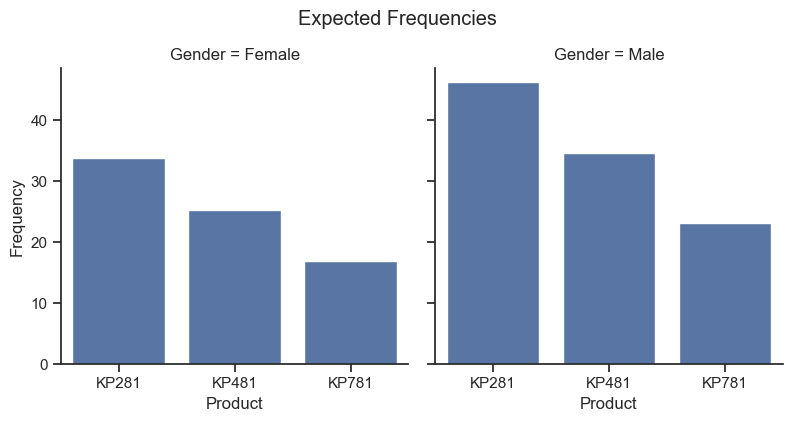

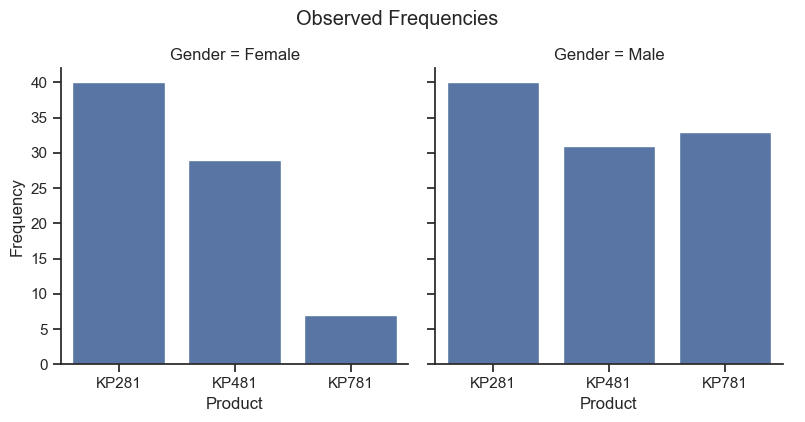


--- Expected Contingency Table ---


Gender,Female,Male
Product,,
KP281,33.7778,46.2222
KP481,25.3333,34.6667
KP781,16.8889,23.1111



--- Observed Contingency Table ---


Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33



--- Pearson Test Summary ---


,test,lambda,chi2,dof,pval,cramer,power,Conclusion,Effect Size
0,pearson,1.0,12.9238,2.0,0.0016,0.268,0.9063,Dependent,Moderate


In [85]:
chi_sq_info('Product', 'Gender', df)

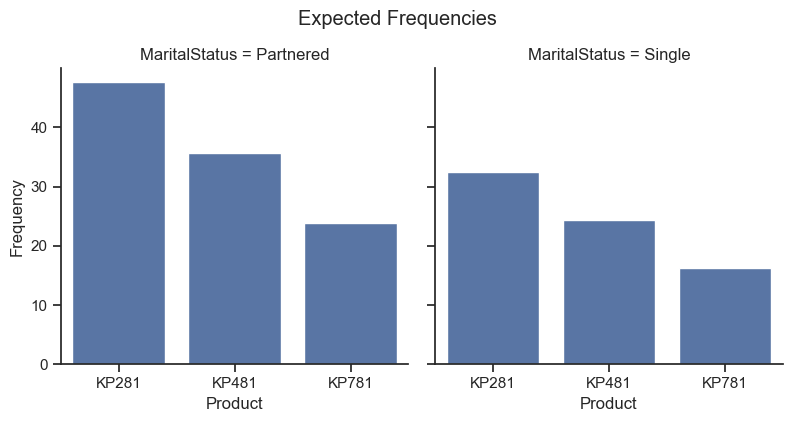

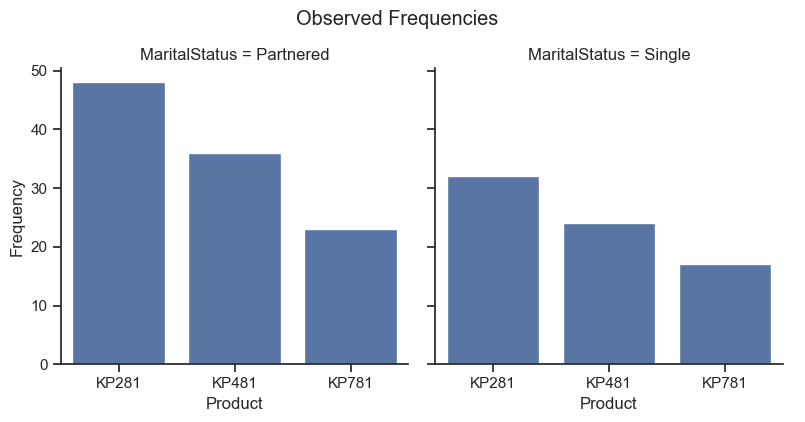


--- Expected Contingency Table ---


MaritalStatus,Partnered,Single
Product,,
KP281,47.5556,32.4444
KP481,35.6667,24.3333
KP781,23.7778,16.2222



--- Observed Contingency Table ---


MaritalStatus,Partnered,Single
Product,,
KP281,48,32
KP481,36,24
KP781,23,17



--- Pearson Test Summary ---


,test,lambda,chi2,dof,pval,cramer,power,Conclusion,Effect Size
0,pearson,1.0,0.0807,2.0,0.9605,0.0212,0.0561,Independent,Weak


In [86]:
chi_sq_info('Product', 'MaritalStatus', df)